In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import heapq
from dataclasses import dataclass
from typing import List, Tuple, Dict
import seaborn as sns
from datetime import datetime
import warnings

In [5]:
df = pd.read_csv(r'C:\CSE163\eda\Crimes_-_2001_to_Present.csv',nrows=10000)
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,11048302,JA383675,08/07/2017 07:00:00 PM,071XX S MICHIGAN AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,...,6.0,69.0,14,1178401.0,1857636.0,2017,02/10/2018 03:50:01 PM,41.764660,-87.621669,"(41.764659745, -87.621669459)"
9996,11048313,JA383721,01/16/2016 06:53:00 PM,087XX W FOSTER AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,True,True,...,41.0,76.0,26,1117233.0,1933399.0,2016,02/10/2018 03:50:01 PM,41.973736,-87.844290,"(41.973736379, -87.844290113)"
9997,11048426,JA383736,08/07/2017 02:00:00 PM,003XX S DAMEN AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,2.0,28.0,06,1163119.0,1898512.0,2017,02/10/2018 03:50:01 PM,41.877161,-87.676537,"(41.877161446, -87.676536946)"
9998,11048516,JA377328,08/04/2017 05:45:00 PM,0000X W CHECKPOINT 7 ST,0820,THEFT,$500 AND UNDER,AIRPORT TERMINAL UPPER LEVEL - SECURE AREA,False,False,...,41.0,76.0,06,1101708.0,1934306.0,2017,02/10/2018 03:50:01 PM,41.976454,-87.901365,"(41.976454319, -87.901364605)"


In [6]:
df['Primary Type'].unique()
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,11048302,JA383675,08/07/2017 07:00:00 PM,071XX S MICHIGAN AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE-GARAGE,False,False,...,6.0,69.0,14,1178401.0,1857636.0,2017,02/10/2018 03:50:01 PM,41.764660,-87.621669,"(41.764659745, -87.621669459)"
9996,11048313,JA383721,01/16/2016 06:53:00 PM,087XX W FOSTER AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,True,True,...,41.0,76.0,26,1117233.0,1933399.0,2016,02/10/2018 03:50:01 PM,41.973736,-87.844290,"(41.973736379, -87.844290113)"
9997,11048426,JA383736,08/07/2017 02:00:00 PM,003XX S DAMEN AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,2.0,28.0,06,1163119.0,1898512.0,2017,02/10/2018 03:50:01 PM,41.877161,-87.676537,"(41.877161446, -87.676536946)"
9998,11048516,JA377328,08/04/2017 05:45:00 PM,0000X W CHECKPOINT 7 ST,0820,THEFT,$500 AND UNDER,AIRPORT TERMINAL UPPER LEVEL - SECURE AREA,False,False,...,41.0,76.0,06,1101708.0,1934306.0,2017,02/10/2018 03:50:01 PM,41.976454,-87.901365,"(41.976454319, -87.901364605)"


In [10]:
tier1_tourism_crimes = [
    'ROBBERY',
    'THEFT',
    'BATTERY',
    'ASSAULT'
]

tier2_tourism_crimes = [
    'BURGLARY',
    'MOTOR VEHICLE THEFT',
    'CRIM SEXUAL ASSAULT',
    'CRIMINAL SEXUAL ASSAULT',
    'KIDNAPPING',
    'STALKING',
    'HUMAN TRAFFICKING'
]

In [7]:
df = pd.read_csv(r'C:\CSE163\eda\Crimes_-_2001_to_Present.csv',nrows=20000)


"""
convert x cor and y coor into lat&long
"""
df_temp = df.dropna(subset=["X Coordinate", "Y Coordinate"])
gdf = gpd.GeoDataFrame(df_temp,geometry=gpd.points_from_xy(df_temp["X Coordinate"], df_temp["Y Coordinate"]),
crs= 'EPSG:3435')
gdf = gdf.to_crs(epsg=4326)

✅ 已保存为 tier_heatmap.png


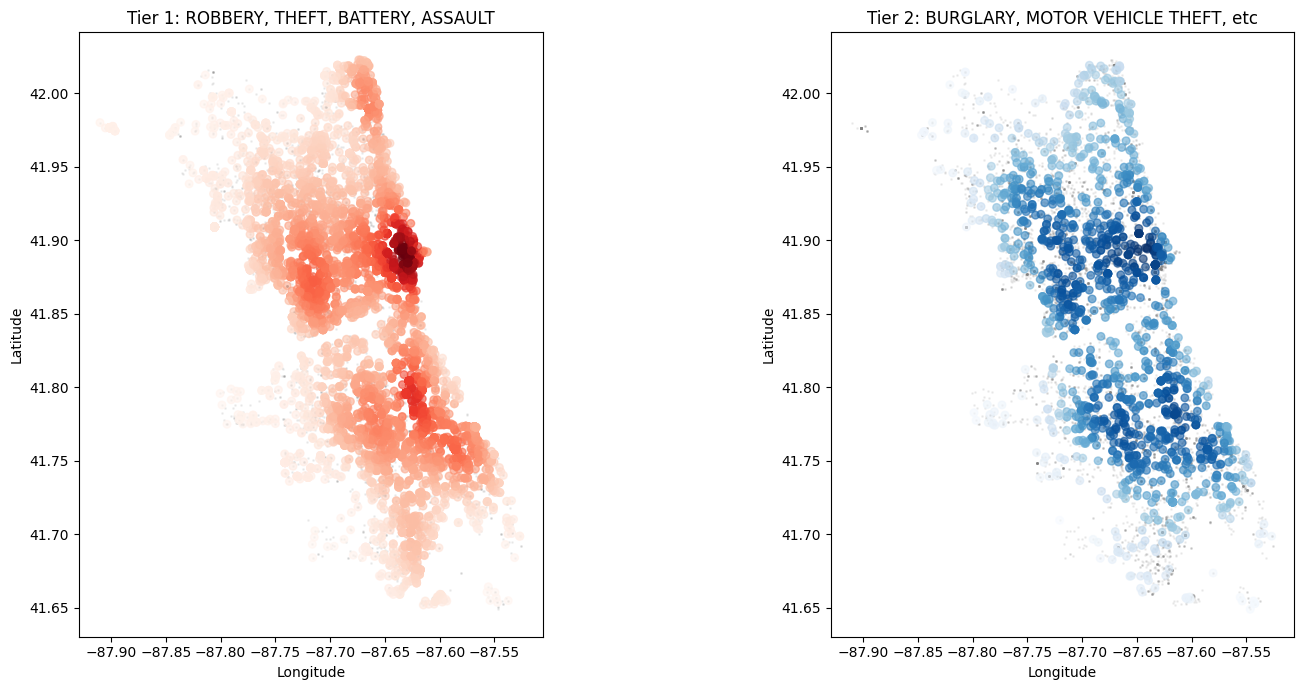

In [ ]:
from scipy.stats import gaussian_kde
gdf_tier1 = gdf[gdf['Primary Type'].isin(tier1_tourism_crimes)]
gdf_tier2 = gdf[gdf['Primary Type'].isin(tier2_tourism_crimes)]


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Tier 1
ax1 = axes[0]
gdf.plot(ax=ax1, alpha=0.1, color='gray', markersize=1)  # 背景
xy1 = np.vstack([gdf_tier1.geometry.x, gdf_tier1.geometry.y])
z1 = gaussian_kde(xy1)(xy1)
ax1.scatter(gdf_tier1.geometry.x, gdf_tier1.geometry.y, c=z1, cmap='Reds', s=30, alpha=0.6)
ax1.set_title('Tier 1: ROBBERY, THEFT, BATTERY, ASSAULT')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Tier 2
ax2 = axes[1]
gdf.plot(ax=ax2, alpha=0.1, color='gray', markersize=1)
xy2 = np.vstack([gdf_tier2.geometry.x, gdf_tier2.geometry.y])
z2 = gaussian_kde(xy2)(xy2)
ax2.scatter(gdf_tier2.geometry.x, gdf_tier2.geometry.y, c=z2, cmap='Blues', s=30, alpha=0.6)
ax2.set_title('Tier 2: BURGLARY, MOTOR VEHICLE THEFT, etc')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('tier_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

🚀 Random Forest Regression: Crime Count Prediction

步骤1️⃣: 数据加载和探索
----------------------------------------------------------------------
✓ 加载 20000 条记录
✓ 列: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description']...

✓ Block 列: 20000/20000 非空
✓ Arrest 列: 20000/20000 非空
✓ Date 列: 20000/20000 非空

步骤2️⃣: 特征工程
----------------------------------------------------------------------
✓ 清理后: 20000 条

✓ 创建目标变量: 按Block×Hour统计犯罪数...
✓ Block×Hour 组合数: 16167
✓ 平均每组犯罪数: 1.24
✓ 最多的一组: 26 起犯罪
✓ 特征工程完成，共 16167 行数据

特征统计:
  Block 种类: 8679
  Hour 范围: 0-23
  逮捕率范围: 0.00-0.00

步骤3️⃣: 数据预处理
----------------------------------------------------------------------
✓ Block 编码: 8679 种 → 数字
✓ 特征形状: (16167, 4)
✓ 目标形状: (16167,)
✓ 特征缺失值: 0
✓ 目标缺失值: 0

✓ 训练集: 12933 样本 (80%)
✓ 测试集: 3234 样本 (20%)

步骤4️⃣: 训练随机森林模型
----------------------------------------------------------------------
正在训练... (可能需要几秒钟)
✓ 模型训练完成

步骤5️⃣: 模型评估
-----------------------------------------------------

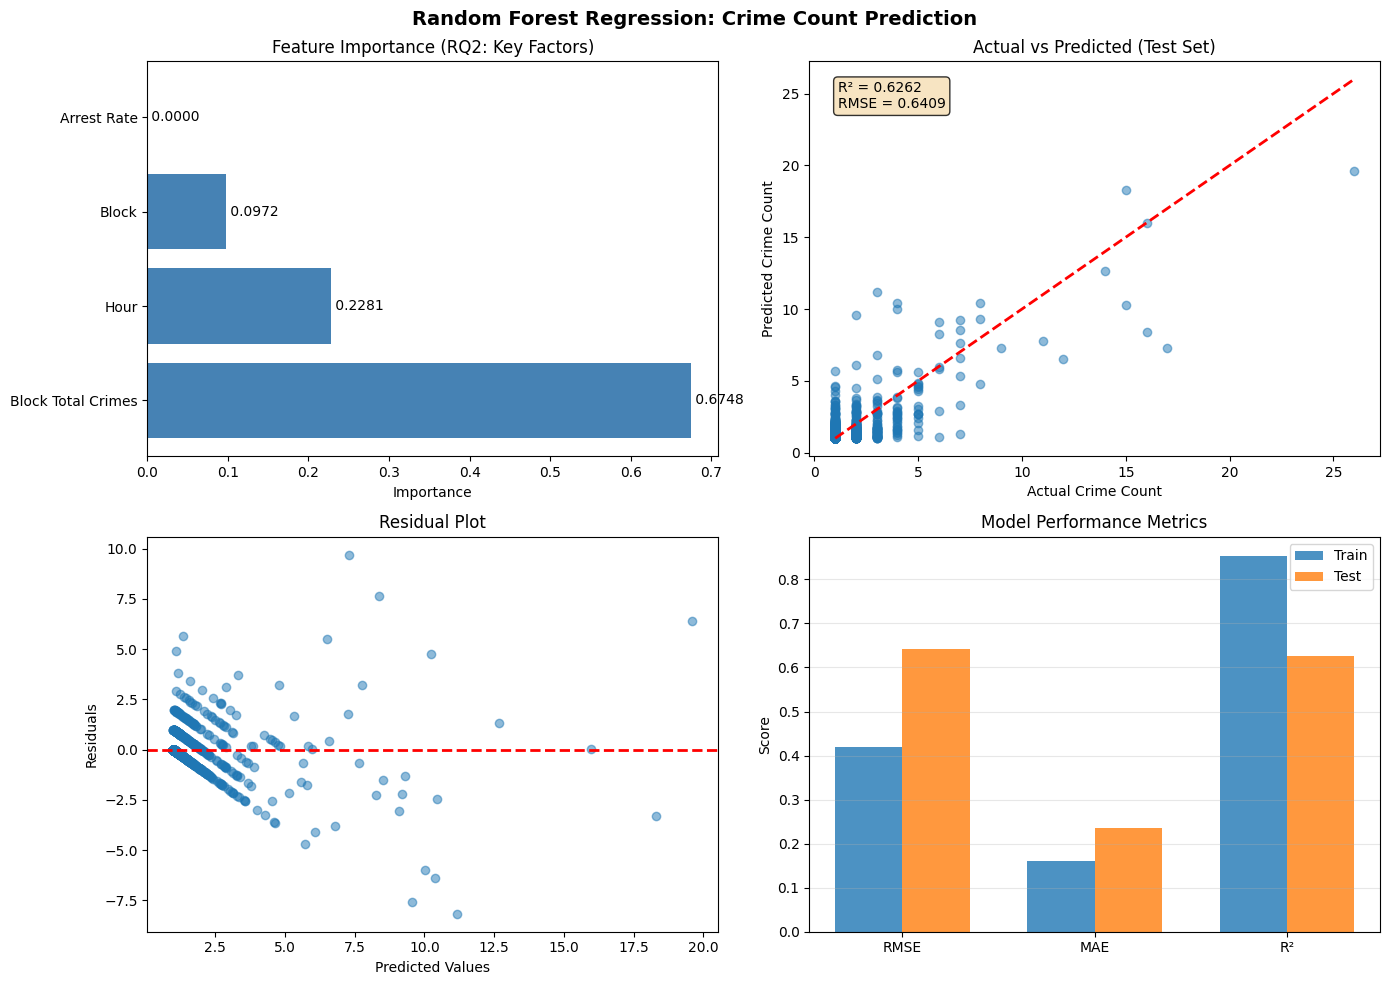


步骤8️⃣: 样本预测
----------------------------------------------------------------------

✅ 所有步骤完成!

📋 总结
----------------------------------------------------------------------

模型: 随机森林回归 (Random Forest Regressor)
数据: 20000 → 16167 (Block×Hour 组合)
特征: Block, Hour, Arrest Rate, Block Total Crimes
目标: 每个Block每小时的犯罪数

性能:
  • 测试集 R² = 0.6262 (模型解释62.6%的方差)
  • 测试集 RMSE = 0.6409 (平均预测误差)

关键发现 (RQ2 - 影响因素):
  1. Block Total Crimes: 67.5%
  2. Hour: 22.8%
  3. Block: 9.7%
  4. Arrest Rate: 0.0%



In [ ]:
"""
随机森林回归模型
预测目标: 每个Block每小时的犯罪数
特征: Block, Hour, Arrested
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error



df = pd.read_csv(r'C:\CSE163\eda\Crimes_-_2001_to_Present.csv', nrows=20000)
print(f"✓ 加载 {len(df)} 条记录")
print(f"✓ 列: {list(df.columns)[:8]}...")

# 检查关键列
print(f"\n✓ Block 列: {df['Block'].notna().sum()}/{len(df)} 非空")
print(f"✓ Arrest 列: {df['Arrest'].notna().sum()}/{len(df)} 非空")
print(f"✓ Date 列: {df['Date'].notna().sum()}/{len(df)} 非空")

# ===== 步骤2: 特征工程 =====
print("\n步骤2️⃣: 特征工程")
print("-" * 70)

# 提取Hour
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Hour'] = df['Date'].dt.hour

# 清理
df_clean = df.dropna(subset=['Block', 'Hour', 'Arrest'])
print(f"✓ 清理后: {len(df_clean)} 条")

# 按Block×Hour分组统计
print("\n✓ 创建目标变量: 按Block×Hour统计犯罪数...")
crime_counts = df_clean.groupby(['Block', 'Hour']).size().reset_index(name='crime_count')
print(f"✓ Block×Hour 组合数: {len(crime_counts)}")
print(f"✓ 平均每组犯罪数: {crime_counts['crime_count'].mean():.2f}")
print(f"✓ 最多的一组: {crime_counts['crime_count'].max()} 起犯罪")

# 计算该Block的总犯罪数(新特征)
block_total_crimes = df_clean.groupby('Block').size().reset_index(name='block_total_crimes')
crime_counts = crime_counts.merge(block_total_crimes, on='Block')

# 计算该Block×Hour的逮捕率
arrest_rates = df_clean.groupby(['Block', 'Hour'])['Arrest'].apply(
    lambda x: (x == 'Y').sum() / len(x) if len(x) > 0 else 0
).reset_index(name='arrest_rate')
crime_counts = crime_counts.merge(arrest_rates, on=['Block', 'Hour'])

print(f"✓ 特征工程完成，共 {len(crime_counts)} 行数据")
print(f"\n特征统计:")
print(f"  Block 种类: {crime_counts['Block'].nunique()}")
print(f"  Hour 范围: {crime_counts['Hour'].min()}-{crime_counts['Hour'].max()}")
print(f"  逮捕率范围: {crime_counts['arrest_rate'].min():.2f}-{crime_counts['arrest_rate'].max():.2f}")

# ===== 步骤3: 数据预处理 =====
print("\n步骤3️⃣: 数据预处理")
print("-" * 70)

# 编码Block (分类变量 → 数字)
le_block = LabelEncoder()
crime_counts['Block_encoded'] = le_block.fit_transform(crime_counts['Block'])
print(f"✓ Block 编码: {crime_counts['Block'].nunique()} 种 → 数字")

# 准备特征和目标
X = crime_counts[['Block_encoded', 'Hour', 'arrest_rate', 'block_total_crimes']]
y = crime_counts['crime_count']

print(f"✓ 特征形状: {X.shape}")
print(f"✓ 目标形状: {y.shape}")

# 检查缺失值
print(f"✓ 特征缺失值: {X.isnull().sum().sum()}")
print(f"✓ 目标缺失值: {y.isnull().sum()}")

# 分割训练/测试集 (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✓ 训练集: {len(X_train)} 样本 (80%)")
print(f"✓ 测试集: {len(X_test)} 样本 (20%)")

# ===== 步骤4: 训练随机森林 =====
print("\n步骤4️⃣: 训练随机森林模型")
print("-" * 70)

print("正在训练... (可能需要几秒钟)")
rf_model = RandomForestRegressor(
    n_estimators=100,      # 100棵树
    max_depth=15,          # 最大深度
    min_samples_split=5,   # 最少样本数
    random_state=42,
    n_jobs=-1              # 使用所有CPU
)

rf_model.fit(X_train, y_train)
print("✓ 模型训练完成")

# ===== 步骤5: 模型评估 =====
print("\n步骤5️⃣: 模型评估")
print("-" * 70)

# 预测
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 计算指标
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\n📊 训练集性能:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\n📊 测试集性能:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")

if test_r2 > 0.7:
    print("\n✅ 模型性能良好 (R² > 0.7)")
elif test_r2 > 0.5:
    print("\n⚠️  模型性能中等 (R² > 0.5)")
else:
    print("\n❌ 模型性能不理想 (R² < 0.5)")

# ===== 步骤6: 特征重要性分析 (RQ2的答案) =====
print("\n步骤6️⃣: 特征重要性分析")
print("-" * 70)

feature_importance = pd.DataFrame({
    'feature': ['Block', 'Hour', 'Arrest Rate', 'Block Total Crimes'],
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n影响犯罪数量的关键因素 (RQ2答案):")
for idx, row in feature_importance.iterrows():
    pct = row['importance'] * 100
    bar = '█' * int(pct / 2)
    print(f"  {row['feature']:20s}: {pct:5.1f}% {bar}")

# ===== 步骤7: 可视化 =====
print("\n步骤7️⃣: 可视化结果")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest Regression: Crime Count Prediction', fontsize=14, fontweight='bold')

# 图1: 特征重要性
ax1 = axes[0, 0]
ax1.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
ax1.set_xlabel('Importance')
ax1.set_title('Feature Importance (RQ2: Key Factors)')
for i, v in enumerate(feature_importance['importance']):
    ax1.text(v, i, f' {v:.4f}', va='center')

# 图2: 实际 vs 预测
ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_test, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Crime Count')
ax2.set_ylabel('Predicted Crime Count')
ax2.set_title('Actual vs Predicted (Test Set)')
ax2.text(0.05, 0.95, f'R² = {test_r2:.4f}\nRMSE = {test_rmse:.4f}',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 图3: 残差分析
ax3 = axes[1, 0]
residuals = y_test - y_pred_test
ax3.scatter(y_pred_test, residuals, alpha=0.5)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residual Plot')

# 图4: 模型性能对比
ax4 = axes[1, 1]
metrics = ['RMSE', 'MAE', 'R²']
train_vals = [train_rmse, train_mae, train_r2]
test_vals = [test_rmse, test_mae, test_r2]

x = np.arange(len(metrics))
width = 0.35

ax4.bar(x - width/2, train_vals, width, label='Train', alpha=0.8)
ax4.bar(x + width/2, test_vals, width, label='Test', alpha=0.8)
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Metrics')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rf_crime_prediction.png', dpi=300, bbox_inches='tight')
print("✓ 可视化已保存为 'rf_crime_prediction.png'")
plt.show()

# ===== 步骤8: 样本预测 =====
print("\n步骤8️⃣: 样本预测")
print("-" * 70)

# 预测例子：Block "001", Hour 12, 逮捕率 0.5
sample_block = "001"
sample_hour = 12
sample_arrest_rate = 0.5

if sample_block in le_block.classes_:
    sample_X = pd.DataFrame({
        'Block_encoded': [le_block.transform([sample_block])[0]],
        'Hour': [sample_hour],
        'arrest_rate': [sample_arrest_rate],
        'block_total_crimes': [block_total_crimes[block_total_crimes['Block']==sample_block]['block_total_crimes'].values[0]]
    })
    
    prediction = rf_model.predict(sample_X)[0]
    print(f"\n示例预测:")
    print(f"  Block: {sample_block}")
    print(f"  Hour: {sample_hour}:00")
    print(f"  Arrest Rate: {sample_arrest_rate:.1%}")
    print(f"  预测犯罪数: {prediction:.1f} 起")

print("\n" + "="*70)
print("✅ 所有步骤完成!")
print("="*70)

# ===== 总结 =====
print("\n📋 总结")
print("-" * 70)
print(f"""
模型: 随机森林回归 (Random Forest Regressor)
数据: {len(df)} → {len(crime_counts)} (Block×Hour 组合)
特征: Block, Hour, Arrest Rate, Block Total Crimes
目标: 每个Block每小时的犯罪数

性能:
  • 测试集 R² = {test_r2:.4f} (模型解释{test_r2*100:.1f}%的方差)
  • 测试集 RMSE = {test_rmse:.4f} (平均预测误差)

关键发现 (RQ2 - 影响因素):
  1. {feature_importance.iloc[0]['feature']}: {feature_importance.iloc[0]['importance']*100:.1f}%
  2. {feature_importance.iloc[1]['feature']}: {feature_importance.iloc[1]['importance']*100:.1f}%
  3. {feature_importance.iloc[2]['feature']}: {feature_importance.iloc[2]['importance']*100:.1f}%
  4. {feature_importance.iloc[3]['feature']}: {feature_importance.iloc[3]['importance']*100:.1f}%
""")